Rigours Iterative Pruning: Without Pruning
- This is the first verison of the code that does not have fine tuning, not match with the rest of our models and the baseline.
- This goes against how RPG works though, it use fine tuning to maintain accuracy, the paper this was based on emphiases the gradation (iterative prune + recover), its a core part of the method
- This was made into a different file (rpg_with_ft.ipynb)

------------------------------------------------------------------------------------------------------------------------------------------------------------

Rough Overview of results
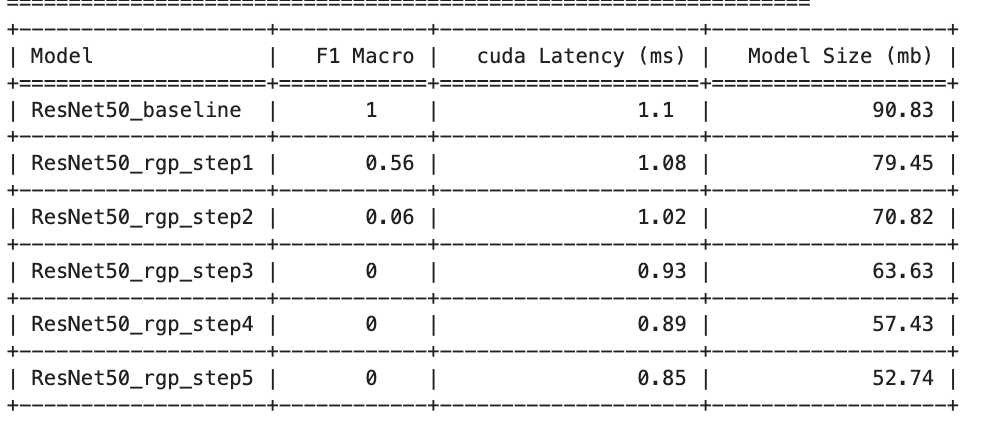
- The F1 has a sharp drop due to its lack of pruning, the accuracy wasnt recovered
- The latency saw a 23% reduction
- The size saw a 42% reduction

In [1]:
import os, sys, copy
import torch
import torch.nn as nn
import pandas as pd
from tqdm.auto import tqdm
from collections import OrderedDict
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split

# navigate to project root
target = "CS6423_knowledge_distillation_project"
if not os.getcwd().endswith(target):
    os.chdir(os.path.join(os.getcwd(), target))
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print(f"Working dir: {os.getcwd()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Working dir: /home/kod6/CS6423_knowledge_distillation_project
Device: cuda


In [2]:
import sys
!{sys.executable} -m pip install timm tabulate
from modules.dataset import radImageDataset
from modules.evaluate_model import ModelEvaluator
from modules.model_trainer import modelTrainer
print("radImageDataset, ModelEvaluator, modelTrainer imported")

Defaulting to user installation because normal site-packages is not writeable
radImageDataset, ModelEvaluator, modelTrainer imported


In [3]:
#load data with radImageDataset
IMAGES_DIR = "data/test_images"
LABELS_CSV = "data/labels.csv"
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

df = pd.read_csv(LABELS_CSV)
print(f"Labels CSV: {len(df)} rows, columns: {df.columns.tolist()}")
print(df.head(3))

# use the project's existing radImageDataset directly
full_dataset = radImageDataset(dataframe=df, image_dir=IMAGES_DIR, transform=transform)
CLASS_NAMES  = full_dataset.class_names
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\nClasses: {NUM_CLASSES} | e.g. {list(CLASS_NAMES[:5])}")

# 80/20 train/val split
n_val   = max(1, int(0.2 * len(full_dataset)))
n_train = len(full_dataset) - n_val
train_set, val_set = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f"Train: {len(train_set)} | Val: {len(val_set)}")

Labels CSV: 9000 rows, columns: ['filename', 'pathology', 'modality', 'location', 'label']
     filename          pathology modality    location  \
0  test_0.png  flexor_pathology_      mri  ankle foot   
1  test_1.png  flexor_pathology_      mri  ankle foot   
2  test_2.png  flexor_pathology_      mri  ankle foot   

                          label  
0  ankle_foot_flexor_pathology_  
1  ankle_foot_flexor_pathology_  
2  ankle_foot_flexor_pathology_  

Classes: 122 | e.g. ['abdomen_abnormal_entire_organ', 'abdomen_adrenal_pathology', 'abdomen_arterial_pathology', 'abdomen_ascites', 'abdomen_bil_dil']
Train: 7200 | Val: 1800


In [4]:
# Load ResNet50 using ImagenetLoader with freeze_backbone
from modules.imagenet_loader import ImagenetLoader

WEIGHTS_PATH = "trained_models/resnet50_baseline/resnet50_baseline.pth"

loader = ImagenetLoader()
model = loader.load_radimagenet_resnet50(
    weights_path=WEIGHTS_PATH,
    load_type="load"   # loads weights into the 122-class head directly
)
loader.freeze_backbone()  # freeze everything except fc
model = model.to(device)

print(f"ResNet50 loaded via ImagenetLoader")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

ResNet50 loaded via ImagenetLoader
Total params: 23,758,010
Trainable params: 249,978


In [5]:
# Train fc head only (backbone frozen) for 10 epochs
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-3
)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(10):
    total_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/10"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1} | loss: {total_loss/len(train_loader):.4f}")

# Unfreeze everything for pruning
for param in model.parameters():
    param.requires_grad = True
print("fc trained, all layers unfrozen — ready for pruning")


Epoch 1/10:   0%|          | 0/225 [00:00<?, ?it/s]

  Epoch 1 | loss: 0.3012


Epoch 2/10:   0%|          | 0/225 [00:00<?, ?it/s]

  Epoch 2 | loss: 0.2260


Epoch 3/10:   0%|          | 0/225 [00:00<?, ?it/s]

...

  Epoch 8 | loss: 0.1148


Epoch 9/10:   0%|          | 0/225 [00:00<?, ?it/s]

  Epoch 9 | loss: 0.1127


Epoch 10/10:   0%|          | 0/225 [00:00<?, ?it/s]

  Epoch 10 | loss: 0.1029
fc trained, all layers unfrozen — ready for pruning


In [6]:
#baseline evalution using ModelEvaluator
evaluator = ModelEvaluator(data_loader=val_loader, class_names=CLASS_NAMES, device=str(device))
baseline_metrics = evaluator.evaluate_single(model, model_name="ResNet50_baseline")

BASELINE_F1 = baseline_metrics["f1_macro"]
print(f"\nBaseline F1 macro:  {baseline_metrics['f1_macro']:.4f}")
print(f"Baseline F1 micro:  {baseline_metrics['f1_micro']:.4f}")
print(f"Baseline latency:   {baseline_metrics['avg_latency_ms']:.2f} ms/sample")
print(f"Baseline size:      {baseline_metrics['model_size_mb']:.2f} MB")


Warming up ResNet50_baseline...
Running inference...

Baseline F1 macro:  0.9977
Baseline F1 micro:  0.9944
Baseline latency:   1.10 ms/sample
Baseline size:      90.83 MB


In [7]:
#DFOT Scorer (part of paper)
class DFOTScorer:
    def __init__(self, model, alpha=0.5):
        self.model   = model
        self.alpha   = alpha
        self._hooks  = []
        self._bufs   = {}
        self._counts = {}

    def register_hooks(self):
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d):
                h = module.weight.register_hook(self._make_hook(name, module))
                self._hooks.append(h)
                self._bufs[name]   = None
                self._counts[name] = 0

    def _make_hook(self, name, module):
        def hook(grad):
            with torch.no_grad():
                raw      = (module.weight.detach() * grad).abs().pow(self.alpha)
                f_scores = raw.view(raw.shape[0], -1).sum(dim=1)
                if self._bufs[name] is None:
                    self._bufs[name] = f_scores.clone()
                else:
                    self._bufs[name] += f_scores
                self._counts[name] += 1
        return hook

    def get_scores(self, normalize=True):
        scores = {}
        for name, buf in self._bufs.items():
            if buf is None:
                continue
            s = buf / max(self._counts[name], 1)
            if normalize:
                s = s / (s.mean() + 1e-8)
            scores[name] = s
        return scores

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []


def compute_dfot_scores(model, loader, device, criterion, alpha=0.5, n_batches=10):
    model.train()
    scorer = DFOTScorer(model, alpha=alpha)
    scorer.register_hooks()
    for i, (imgs, labels) in enumerate(loader):
        if i >= n_batches:
            break
        imgs, labels = imgs.to(device), labels.to(device)
        model.zero_grad()
        loss = criterion(model(imgs)[:, :NUM_CLASSES], labels)
        loss.backward()
    scores = scorer.get_scores(normalize=True)
    scorer.remove_hooks()
    model.zero_grad()
    return scores

print("DFOTScorer defined")

DFOTScorer defined


In [8]:
#layer significance assement
def assess_layer_significance(model, val_loader, device, class_names, top_k=3):
    print("\n=== Layer Significance Assessment ===")
    ev       = ModelEvaluator(val_loader, class_names=class_names, device=str(device))
    base_f1  = ev.evaluate_single(model, "base")["f1_macro"]
    print(f"  Baseline F1: {base_f1:.4f}")

    results     = []
    conv_layers = [(n, m) for n, m in model.named_modules() if isinstance(m, nn.Conv2d)]

    for name, module in tqdm(conv_layers, desc="Significance scan"):
        h   = module.register_forward_hook(lambda mod, inp, out: torch.zeros_like(out))
        f1  = ev.evaluate_single(model, name)["f1_macro"]
        h.remove()
        results.append({"layer": name, "f1_zeroed": f1, "f1_drop": base_f1 - f1})

    df        = pd.DataFrame(results).sort_values("f1_drop", ascending=False)
    df.to_csv("layer_significance.csv", index=False)
    protected = df.head(top_k)["layer"].tolist()

    print(f"\n  Protecting top-{top_k} layers:")
    for p in protected:
        row = df[df["layer"] == p].iloc[0]
        print(f"    {p}  (F1 drop={row['f1_drop']:.4f})")
    return protected, df

protected_layers, sig_df = assess_layer_significance(
    model, val_loader, device, CLASS_NAMES, top_k=3
)


=== Layer Significance Assessment ===

Warming up base...
Running inference...
  Baseline F1: 0.9977


Significance scan:   0%|          | 0/53 [00:00<?, ?it/s]


Warming up conv1...
Running inference...

Warming up layer1.0.conv1...
Running inference...

Warming up layer1.0.conv2...
Running inference...

Warming up layer1.0.conv3...
Running inference...

Warming up layer1.0.downsample.0...
Running inference...

Warming up layer1.1.conv1...
Running inference...

Warming up layer1.1.conv2...
Running inference...

Warming up layer1.1.conv3...
Running inference...

Warming up layer1.2.conv1...
Running inference...

Warming up layer1.2.conv2...
Running inference...

Warming up layer1.2.conv3...
Running inference...

Warming up layer2.0.conv1...
Running inference...

Warming up layer2.0.conv2...
Running inference...

Warming up layer2.0.conv3...
Running inference...

Warming up layer2.0.downsample.0...
Running inference...

Warming up layer2.1.conv1...
Running inference...

Warming up layer2.1.conv2...
Running inference...

Warming up layer2.1.conv3...
Running inference...

Warming up layer2.2.conv1...
Running inference...

Warming up layer2.2.conv2

In [9]:
# Global mask registry
pruning_mask = {}

def get_filters_to_prune(scores, prune_ratio, protected_layers):
    all_entries = []
    for layer_name, filter_scores in scores.items():
        # skip conv3 and downsample — skip-coupled
        if any(x in layer_name for x in ["conv3", "downsample"]):
            continue
        if any(p == layer_name for p in protected_layers):
            continue
        already_pruned = pruning_mask.get(layer_name, [])
        for f_idx, score in enumerate(filter_scores.cpu().tolist()):
            if f_idx not in already_pruned:
                all_entries.append((score, layer_name, f_idx))

    all_entries.sort(key=lambda x: x[0])
    n_prune = int(len(all_entries) * prune_ratio)
    prune_map = {}
    for _, layer_name, f_idx in all_entries[:n_prune]:
        prune_map.setdefault(layer_name, []).append(f_idx)
    return prune_map, n_prune


def structured_prune(model, prune_map):

    def set_module(model, name, new_module):
        parts = name.split(".")
        parent = model
        for p in parts[:-1]:
            parent = getattr(parent, p)
        setattr(parent, parts[-1], new_module)

    def prune_conv_out(conv, keep):
        new = nn.Conv2d(conv.in_channels, len(keep), conv.kernel_size,
                        stride=conv.stride, padding=conv.padding,
                        bias=conv.bias is not None)
        with torch.no_grad():
            new.weight.copy_(conv.weight[keep])
            if conv.bias is not None:
                new.bias.copy_(conv.bias[keep])
        return new

    def prune_conv_in(conv, keep):
        new = nn.Conv2d(len(keep), conv.out_channels, conv.kernel_size,
                        stride=conv.stride, padding=conv.padding,
                        bias=conv.bias is not None)
        with torch.no_grad():
            new.weight.copy_(conv.weight[:, keep, :, :])
            if conv.bias is not None:
                new.bias.copy_(conv.bias)
        return new

    def prune_bn(bn, keep):
        new = nn.BatchNorm2d(len(keep))
        with torch.no_grad():
            new.weight.copy_(bn.weight[keep])
            new.bias.copy_(bn.bias[keep])
            new.running_mean.copy_(bn.running_mean[keep])
            new.running_var.copy_(bn.running_var[keep])
        return new

    def get_module(model, name):
        """Always fetch live from model — never use stale dict."""
        m = model
        for p in name.split("."):
            m = getattr(m, p)
        return m

    for layer_name, prune_indices in prune_map.items():
        # skip conv3 and downsample — skip-coupled
        if "conv3" in layer_name or "downsample" in layer_name:
            print(f"  Skipping {layer_name} — skip-coupled")
            continue

        try:
            conv = get_module(model, layer_name)
        except AttributeError:
            continue
        if not isinstance(conv, nn.Conv2d):
            continue

        keep = [i for i in range(conv.out_channels) if i not in prune_indices]
        if len(keep) == 0:
            print(f"  ⚠ Skipping {layer_name} — would remove all filters")
            continue

        print(f"  {layer_name}: {conv.out_channels} → {len(keep)} filters")

        # 1. prune conv output
        set_module(model, layer_name, prune_conv_out(conv, keep))

        # 2. prune corresponding BN
        if "conv1" in layer_name:
            bn_name = layer_name.replace("conv1", "bn1")
        elif "conv2" in layer_name:
            bn_name = layer_name.replace("conv2", "bn2")
        else:
            bn_name = None

        if bn_name:
            try:
                bn = get_module(model, bn_name)
                if isinstance(bn, nn.BatchNorm2d):
                    set_module(model, bn_name, prune_bn(bn, keep))
            except AttributeError:
                pass

        # 3. prune next layer's input channels
        parts = layer_name.split(".")

        if layer_name == "conv1":
            # stem conv1 feeds into layer1.0.conv1 main path
            try:
                next_conv = get_module(model, "layer1.0.conv1")
                if isinstance(next_conv, nn.Conv2d):
                    set_module(model, "layer1.0.conv1", prune_conv_in(next_conv, keep))
                    print(f"    → updated layer1.0.conv1 input channels")
            except AttributeError:
                pass

            # stem conv1 also feeds into layer1.0.downsample.0 skip path
            try:
                ds = get_module(model, "layer1.0.downsample.0")
                if isinstance(ds, nn.Conv2d):
                    set_module(model, "layer1.0.downsample.0", prune_conv_in(ds, keep))
                    print(f"    → updated layer1.0.downsample.0 input channels")
            except AttributeError:
                pass

        elif len(parts) == 3:
            layer_group = parts[0]      # e.g. layer1
            block_idx   = int(parts[1]) # e.g. 0
            conv_num    = parts[2]      # e.g. conv1 or conv2

            if conv_num == "conv1":
                # conv1 → conv2 within same block
                next_name = f"{layer_group}.{block_idx}.conv2"
            elif conv_num == "conv2":
                # conv2 → conv3 within same block
                next_name = f"{layer_group}.{block_idx}.conv3"
            else:
                next_name = None

            if next_name:
                try:
                    next_conv = get_module(model, next_name)
                    if isinstance(next_conv, nn.Conv2d):
                        set_module(model, next_name, prune_conv_in(next_conv, keep))
                        print(f"    → updated {next_name} input: → {len(keep)}")
                except AttributeError:
                    pass

        pruning_mask[layer_name] = prune_indices

    total = sum(len(v) for v in pruning_mask.values())
    print(f"  Total filters removed: {total}")
    return model


def get_conv_sparsity(model):
    total_removed = sum(len(v) for v in pruning_mask.values())
    return total_removed / 26496

print("Structured pruning helpers defined")


Structured pruning helpers defined


In [10]:
#fine tuning via modelTrainer
class _MinimalDataPrep:
    """Minimal shim so modelTrainer works without a full DataPrep object.
    modelTrainer only uses .train_loader, .val_loader, .class_names, .class_weights."""
    def __init__(self, train_loader, val_loader, class_names):
        self.train_loader  = train_loader
        self.val_loader    = val_loader
        self.class_names   = class_names
        self.class_weights = None


def finetune_with_trainer(model, train_loader, val_loader,
                           class_names, device, epochs=3, lr=1e-4):
    data_prep = _MinimalDataPrep(train_loader, val_loader, class_names)
    trainer   = modelTrainer(
        model=model, data_prep=data_prep, device=device,
        learn_rate=lr, num_epochs=epochs,
        model_name="rgp_finetune_temp"   # won't save during pruning loop
    )
    trainer.prepare_for_training()

    best_val_f1 = 0.0
    for epoch in range(epochs):
        train_loss, train_f1 = trainer.train_epoch(epoch)
        val_loss,   val_f1   = trainer.validate()
        best_val_f1 = max(best_val_f1, val_f1)
        print(f"  Epoch {epoch+1}/{epochs} | "
              f"train_loss={train_loss:.4f} train_f1={train_f1:.4f} | "
              f"val_loss={val_loss:.4f}   val_f1={val_f1:.4f}")
    return model, best_val_f1

print("Fine-tune wrapper defined")

Fine-tune wrapper defined


In [11]:
#full RGP Pipeline
def rgp_pipeline(
    model,
    train_loader, val_loader, device, class_names,
    pruning_schedule = [0.10, 0.20, 0.30, 0.40, 0.50],
    alpha            = 0.5,
    top_k_protect    = 1,
    finetune_epochs  = 10,
    finetune_lr      = 1e-4,
    n_calib_batches  = 10,
    save_dir         = "rgp_checkpoints",
    early_stop_drop  = 1.0,
):
    os.makedirs(save_dir, exist_ok=True)
    criterion = nn.CrossEntropyLoss()
    ev        = ModelEvaluator(val_loader, class_names=class_names, device=str(device))

    # baseline
    baseline     = ev.evaluate_single(model, "ResNet50_baseline")
    BASELINE_F1  = baseline["f1_macro"]
    print(f"\n{'='*60}")
    print(f"BASELINE  F1={BASELINE_F1:.4f}  "
          f"size={baseline['model_size_mb']:.1f}MB  "
          f"latency={baseline['avg_latency_ms']:.2f}ms")
    print(f"{'='*60}")

    # initial layer significance
    protected_layers, _ = assess_layer_significance(
        model, val_loader, device, class_names, top_k=top_k_protect
    )

    log, cumulative = [], 0.0

    for step, target in enumerate(pruning_schedule):
        print(f"\n{'='*60}")
        print(f"RGP STEP {step+1}/{len(pruning_schedule)} → target: {target*100:.0f}%")
        print(f"{'='*60}")

        incremental = max(0.0, target - cumulative)
        if incremental < 0.01:
            print("  Already at target — skipping.")
            continue
        cumulative = target

        # 2a. DFOT scores
        print(f"  Computing DFOT scores (alpha={alpha})...")
        scores = compute_dfot_scores(model, train_loader, device, criterion,
                                     alpha=alpha, n_batches=n_calib_batches)

        # 2b. Structured prune
        prune_map, n_prune = get_filters_to_prune(scores, incremental, protected_layers)
        model = structured_prune(model, prune_map)
        sparsity = get_conv_sparsity(model)
        print(f"  Sparsity: {sparsity*100:.1f}%")

        # no fine-tuning — showing raw pruning cost

        # 2c. Full eval via ModelEvaluator
        step_metrics = ev.evaluate_single(model, f"ResNet50_rgp_step{step+1}")
        f1_drop      = BASELINE_F1 - step_metrics["f1_macro"]

        print(f"\n  ✓ F1={step_metrics['f1_macro']:.4f}  Δ={-f1_drop:+.4f}  "
              f"size={step_metrics['model_size_mb']:.1f}MB  "
              f"latency={step_metrics['avg_latency_ms']:.2f}ms  "
              f"sparsity={sparsity*100:.1f}%")

        log.append(dict(
            step=step+1, target_ratio=target, sparsity=sparsity,
            f1_macro=step_metrics["f1_macro"], f1_micro=step_metrics["f1_micro"],
            sensitivity=step_metrics["sensitivity"], f1_drop=f1_drop,
            latency_ms=step_metrics["avg_latency_ms"], size_mb=step_metrics["model_size_mb"],
        ))

        # save checkpoint
        ckpt_name = f"resnet50_rgp_step{step+1}_{int(target*100)}pct"
        ckpt_dir  = os.path.join(save_dir, ckpt_name)
        os.makedirs(ckpt_dir, exist_ok=True)
        torch.save(
            {"model": model.state_dict(), "epoch": step+1,
             "sparsity": sparsity, "f1_macro": step_metrics["f1_macro"]},
            os.path.join(ckpt_dir, f"{ckpt_name}.pth")
        )
        print(f"  Saved → {ckpt_dir}/{ckpt_name}.pth")

        # iterative reassessment
        print("  Reassessing layer significance...")
        protected_layers, _ = assess_layer_significance(
            model, val_loader, device, class_names, top_k=top_k_protect
        )

        if f1_drop > early_stop_drop:
            print(f"\n F1 drop {f1_drop:.4f} > threshold — stopping early.")
            break

    log_df = pd.DataFrame(log)
    log_df.to_csv(os.path.join(save_dir, "rgp_log.csv"), index=False)
    print(f"\n{'='*60}\nRGP COMPLETE\n{log_df.to_string(index=False)}\n{'='*60}")
    ev.display_summary()
    return model, log_df

print("rgp_pipeline defined")

rgp_pipeline defined


In [12]:
#run RGP
pruned_model, log_df = rgp_pipeline(
    model            = model,
    train_loader     = train_loader,
    val_loader       = val_loader,
    device           = device,
    class_names      = CLASS_NAMES,
    #pruning_schedule = [0.10, 0.10, 0.10, 0.10, 0.10],  # 10% incremental each step,
    pruning_schedule = [0.10, 0.20, 0.30, 0.40, 0.50],
    alpha            = 0.5,       # DFOT desensitization exponent — tune in Cell 12
    top_k_protect    = 1,
    finetune_epochs  = 10,         # increase to 5-10 for better recovery
    finetune_lr      = 1e-4,      # ~10x smaller than original training LR
    n_calib_batches  = 10,
    save_dir         = "rgp_checkpoints",
    early_stop_drop = 1.0,
)


Warming up ResNet50_baseline...
Running inference...

BASELINE  F1=0.9977  size=90.8MB  latency=1.10ms

=== Layer Significance Assessment ===

Warming up base...
Running inference...
  Baseline F1: 0.9977


Significance scan:   0%|          | 0/53 [00:00<?, ?it/s]


Warming up conv1...
Running inference...

Warming up layer1.0.conv1...
Running inference...

Warming up layer1.0.conv2...
Running inference...

Warming up layer1.0.conv3...
Running inference...

Warming up layer1.0.downsample.0...
Running inference...

Warming up layer1.1.conv1...
Running inference...

Warming up layer1.1.conv2...
Running inference...

Warming up layer1.1.conv3...
Running inference...

Warming up layer1.2.conv1...
Running inference...

Warming up layer1.2.conv2...
Running inference...

Warming up layer1.2.conv3...
Running inference...

Warming up layer2.0.conv1...
Running inference...

Warming up layer2.0.conv2...
Running inference...

Warming up layer2.0.conv3...
Running inference...

Warming up layer2.0.downsample.0...
Running inference...

Warming up layer2.1.conv1...
Running inference...

Warming up layer2.1.conv2...
Running inference...

Warming up layer2.1.conv3...
Running inference...

Warming up layer2.2.conv1...
Running inference...

Warming up layer2.2.conv2

Significance scan:   0%|          | 0/53 [00:00<?, ?it/s]


Warming up conv1...
Running inference...

Warming up layer1.0.conv1...
Running inference...

Warming up layer1.0.conv2...
Running inference...

Warming up layer1.0.conv3...
Running inference...

Warming up layer1.0.downsample.0...
Running inference...

Warming up layer1.1.conv1...
Running inference...

Warming up layer1.1.conv2...
Running inference...

Warming up layer1.1.conv3...
Running inference...

Warming up layer1.2.conv1...
Running inference...

Warming up layer1.2.conv2...
Running inference...

Warming up layer1.2.conv3...
Running inference...

Warming up layer2.0.conv1...
Running inference...

Warming up layer2.0.conv2...
Running inference...

Warming up layer2.0.conv3...
Running inference...

Warming up layer2.0.downsample.0...
Running inference...

Warming up layer2.1.conv1...
Running inference...

Warming up layer2.1.conv2...
Running inference...

Warming up layer2.1.conv3...
Running inference...

Warming up layer2.2.conv1...
Running inference...

Warming up layer2.2.conv2

...


Warming up conv1...
Running inference...

Warming up layer1.0.conv1...
Running inference...

Warming up layer1.0.conv2...
Running inference...

Warming up layer1.0.conv3...
Running inference...

Warming up layer1.0.downsample.0...
Running inference...

Warming up layer1.1.conv1...
Running inference...

Warming up layer1.1.conv2...
Running inference...

Warming up layer1.1.conv3...
Running inference...

Warming up layer1.2.conv1...
Running inference...

Warming up layer1.2.conv2...
Running inference...

Warming up layer1.2.conv3...
Running inference...

Warming up layer2.0.conv1...
Running inference...

Warming up layer2.0.conv2...
Running inference...

Warming up layer2.0.conv3...
Running inference...

Warming up layer2.0.downsample.0...
Running inference...

Warming up layer2.1.conv1...
Running inference...

Warming up layer2.1.conv2...
Running inference...

Warming up layer2.1.conv3...
Running inference...

Warming up layer2.2.conv1...
Running inference...

Warming up layer2.2.conv2

Significance scan:   0%|          | 0/53 [00:00<?, ?it/s]


Warming up conv1...
Running inference...

Warming up layer1.0.conv1...
Running inference...

Warming up layer1.0.conv2...
Running inference...

Warming up layer1.0.conv3...
Running inference...

Warming up layer1.0.downsample.0...
Running inference...

Warming up layer1.1.conv1...
Running inference...

Warming up layer1.1.conv2...
Running inference...

Warming up layer1.1.conv3...
Running inference...

Warming up layer1.2.conv1...
Running inference...

Warming up layer1.2.conv2...
Running inference...

Warming up layer1.2.conv3...
Running inference...

Warming up layer2.0.conv1...
Running inference...

Warming up layer2.0.conv2...
Running inference...

Warming up layer2.0.conv3...
Running inference...

Warming up layer2.0.downsample.0...
Running inference...

Warming up layer2.1.conv1...
Running inference...

Warming up layer2.1.conv2...
Running inference...

Warming up layer2.1.conv3...
Running inference...

Warming up layer2.2.conv1...
Running inference...

Warming up layer2.2.conv2

Significance scan:   0%|          | 0/53 [00:00<?, ?it/s]


Warming up conv1...
Running inference...

Warming up layer1.0.conv1...
Running inference...

Warming up layer1.0.conv2...
Running inference...

Warming up layer1.0.conv3...
Running inference...

Warming up layer1.0.downsample.0...
Running inference...

Warming up layer1.1.conv1...
Running inference...

Warming up layer1.1.conv2...
Running inference...

Warming up layer1.1.conv3...
Running inference...

Warming up layer1.2.conv1...
Running inference...

Warming up layer1.2.conv2...
Running inference...

Warming up layer1.2.conv3...
Running inference...

Warming up layer2.0.conv1...
Running inference...

Warming up layer2.0.conv2...
Running inference...

Warming up layer2.0.conv3...
Running inference...

Warming up layer2.0.downsample.0...
Running inference...

Warming up layer2.1.conv1...
Running inference...

Warming up layer2.1.conv2...
Running inference...

Warming up layer2.1.conv3...
Running inference...

Warming up layer2.2.conv1...
Running inference...

Warming up layer2.2.conv2

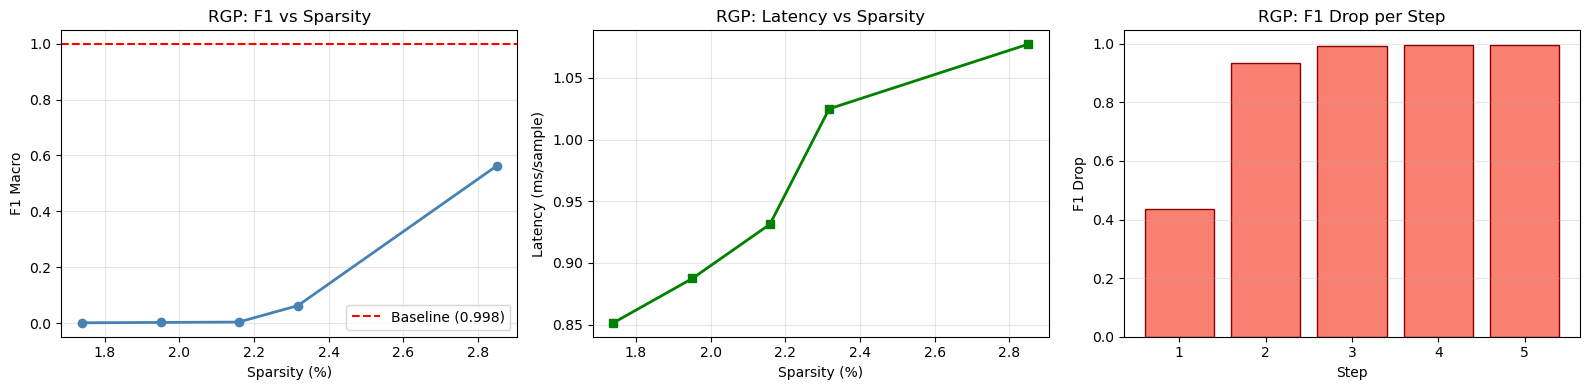

Saved → rgp_checkpoints/rgp_results.png
Import rgp_checkpoints/rgp_log.csv in graphing.ipynb for combined plots


In [13]:
#visulaise
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(log_df["sparsity"]*100, log_df["f1_macro"], "o-", color="steelblue", lw=2)
axes[0].axhline(BASELINE_F1, color="red", linestyle="--", label=f"Baseline ({BASELINE_F1:.3f})")
axes[0].set_xlabel("Sparsity (%)"); axes[0].set_ylabel("F1 Macro")
axes[0].set_title("RGP: F1 vs Sparsity"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(log_df["sparsity"]*100, log_df["latency_ms"], "s-", color="green", lw=2)
axes[1].set_xlabel("Sparsity (%)"); axes[1].set_ylabel("Latency (ms/sample)")
axes[1].set_title("RGP: Latency vs Sparsity"); axes[1].grid(True, alpha=0.3)

axes[2].bar(log_df["step"], log_df["f1_drop"], color="salmon", edgecolor="darkred")
axes[2].set_xlabel("Step"); axes[2].set_ylabel("F1 Drop")
axes[2].set_title("RGP: F1 Drop per Step"); axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("rgp_checkpoints/rgp_results.png", dpi=150)
plt.show()
print("Saved → rgp_checkpoints/rgp_results.png")
print("Import rgp_checkpoints/rgp_log.csv in graphing.ipynb for combined plots")